# Explainable and Fair Machine Learning for Community-Based Diabetes Risk Prediction


## Group 4 final results notebook.
This notebook reproduces the final presentation results using the CDC BRFSS 2015 diabetes health indicators dataset.

Main changes after feedback:

1. We do not rely on SMOTE alone.
2. We add class-weighted / sample-weighted learning to reduce majority-class dominance.
3. We include a Neural Network (MLP) as an additional baseline.
4. We use macro-F1, balanced accuracy, class-specific recall, predicted class distribution, and subgroup gaps, rather than accuracy alone.

In [3]:
import os, time, json, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, classification_report, confusion_matrix, recall_score
from sklearn.utils.class_weight import compute_class_weight
try:
    from xgboost import XGBClassifier
    HAS_XGB=True
except Exception:
    HAS_XGB=False

RANDOM_STATE=42
DATA_PATH='diabetes_012_health_indicators_BRFSS2015.csv'
OUT=Path('final_outputs')
OUT.mkdir(exist_ok=True)

## 1. Helper functions
These functions compute class weights, tune the validation decision rule, summarise test metrics, and evaluate subgroup fairness gaps.

In [6]:
def class_weight_dict(y):
    classes=np.sort(np.unique(y))
    weights=compute_class_weight(class_weight='balanced', classes=classes, y=y)
    return {int(c): float(w) for c,w in zip(classes, weights)}

def sample_weights(y, cw):
    return np.array([cw[int(v)] for v in y])

def tune_decision_weights(y_val, proba_val):
    grid1=[1.0,1.25,1.5,2.0,2.5,3.0,4.0]
    grid2=[1.0,1.1,1.25,1.5,1.75,2.0]
    best_score=-1; best_weights=(1.0,1.0); best_pred=None
    for w1 in grid1:
        for w2 in grid2:
            weights=np.array([1.0,w1,w2])
            pred=np.argmax(proba_val*weights, axis=1)
            score=f1_score(y_val, pred, average='macro', zero_division=0)
            # avoid pathological over-prediction of minority classes
            pdist=np.bincount(pred.astype(int), minlength=3)/len(pred)
            if pdist[1] > 0.20: score -= 0.05*(pdist[1]-0.20)
            if pdist[2] > 0.40: score -= 0.05*(pdist[2]-0.40)
            if score>best_score:
                best_score=score; best_weights=(w1,w2); best_pred=pred
    return {'class1_weight':best_weights[0], 'class2_weight':best_weights[1]}, best_pred

def metrics_dict(model_name, y_true, y_pred):
    rec=recall_score(y_true,y_pred,average=None,labels=[0,1,2],zero_division=0)
    pred_dist=np.bincount(y_pred.astype(int), minlength=3)/len(y_pred)
    return {'Model':model_name,'Accuracy':accuracy_score(y_true,y_pred),
            'BalancedAccuracy':balanced_accuracy_score(y_true,y_pred),'MacroF1':f1_score(y_true,y_pred,average='macro',zero_division=0),
            'Recall_Healthy_0':rec[0],'Recall_Prediabetes_1':rec[1],'Recall_Diabetes_2':rec[2],
            'Pred_Healthy_0_pct':pred_dist[0],'Pred_Prediabetes_1_pct':pred_dist[1],'Pred_Diabetes_2_pct':pred_dist[2]}

def subgroup_gaps(X_test, y_true, predictions):
    rows=[]
    for mname, pred in predictions.items():
        temp=X_test[['Sex','Age','Income']].copy(); temp['y_true']=np.asarray(y_true); temp['pred']=np.asarray(pred)
        for feature in ['Sex','Age','Income']:
            vals=[]
            for val in sorted(temp[feature].unique()):
                sub=temp[temp[feature]==val]
                if len(sub)<50: continue
                vals.append((val,len(sub),f1_score(sub['y_true'],sub['pred'],average='macro',zero_division=0),accuracy_score(sub['y_true'],sub['pred'])))
            if vals:
                rows.append({'Model':mname,'SensitiveFeature':feature,'MacroF1_Gap':max(v[2] for v in vals)-min(v[2] for v in vals),
                             'Accuracy_Gap':max(v[3] for v in vals)-min(v[3] for v in vals),
                             'WorstGroup':min(vals,key=lambda x:x[2])[0],'BestGroup':max(vals,key=lambda x:x[2])[0],'GroupsEvaluated':len(vals)})
    return pd.DataFrame(rows)

## 2. Load data and define target/features
The target is Diabetes_012: 0 = healthy/no diabetes, 1 = prediabetes, 2 = diabetes.
Rows are not removed only because they look duplicated, because BRFSS variables are discretised survey indicators; different respondents can share identical indicator patterns.

In [7]:
start = time.time()
df = pd.read_csv(DATA_PATH)
y = df['Diabetes_012'].astype(int)
X = df.drop(columns=['Diabetes_012'])

print('Data shape:', df.shape)
print('Class counts:')
print(y.value_counts().sort_index())
print('\nClass distribution:')
print((y.value_counts(normalize=True).sort_index() * 100).round(2).astype(str) + '%')

Data shape: (253680, 22)
Class counts:
Diabetes_012
0    213703
1      4631
2     35346
Name: count, dtype: int64

Class distribution:
Diabetes_012
0    84.24%
1     1.83%
2    13.93%
Name: proportion, dtype: object


## 3. Experimental design
We use a 60% / 20% / 20% train-validation-test split, stratified by the target class.
The test set remains untouched until the final evaluation.

In [8]:
X_train,X_temp,y_train,y_temp=train_test_split(
    X,y,test_size=0.40,random_state=RANDOM_STATE,stratify=y
)
X_val,X_test,y_val,y_test=train_test_split(
    X_temp,y_temp,test_size=0.50,random_state=RANDOM_STATE,stratify=y_temp
)

cw=class_weight_dict(y_train)
sw_train=sample_weights(y_train,cw)

scaler=StandardScaler()
X_train_s=scaler.fit_transform(X_train)
X_val_s=scaler.transform(X_val)
X_test_s=scaler.transform(X_test)

print('Train:', X_train.shape, 'Validation:', X_val.shape, 'Test:', X_test.shape)
print('Class weights:', cw)

Train: (152208, 21) Validation: (50736, 21) Test: (50736, 21)
Class weights: {0: 0.395688727363479, 1: 18.256926952141058, 2: 2.392417597962937}


## 4. Final baseline models
The teacher's feedback was that using SMOTE alone is not sufficient.
Therefore, the final baseline uses class-aware learning:

·Logistic Regression: balanced class weights.

·Random Forest: balanced subsample class weights.

·XGBoost: balanced sample weights.

·Neural Network / MLP: balanced sample weights and early stopping.
A validation-tuned probability decision rule is used to check whether extra class-priority weights are useful. In the final run, the selected extra weights remained 1.0, meaning the class/sample weighting already gave the best validation macro-F1.

In [10]:
models={}; selection=[]
print('data split', X_train.shape, X_val.shape, X_test.shape, flush=True)
# Logistic regression
print('fit LR', flush=True); t=time.time()
lr=LogisticRegression(max_iter=1000,C=0.5,class_weight=cw,solver='lbfgs',random_state=RANDOM_STATE)
lr.fit(X_train_s,y_train)
tw,pv=tune_decision_weights(y_val,lr.predict_proba(X_val_s)); print('LR val macro',f1_score(y_val,pv,average='macro'),tw,time.time()-t, flush=True)
models['Logistic Regression']=('scaled',lr,tw,'C=0.5, class_weight=balanced')
# Random forest
print('fit RF', flush=True); t=time.time()
rf=RandomForestClassifier(n_estimators=80,max_depth=12,min_samples_leaf=20,n_jobs=-1,random_state=RANDOM_STATE,class_weight='balanced_subsample')
rf.fit(X_train,y_train)
tw,pv=tune_decision_weights(y_val,rf.predict_proba(X_val)); print('RF val macro',f1_score(y_val,pv,average='macro'),tw,time.time()-t, flush=True)
models['Random Forest']=('raw',rf,tw,'80 trees, max_depth=12, class_weight=balanced_subsample')
# XGBoost
if HAS_XGB:
 print('fit XGB', flush=True); t=time.time()
 xgb=XGBClassifier(objective='multi:softprob',num_class=3,eval_metric='mlogloss',n_estimators=30,max_depth=3,learning_rate=0.1,subsample=0.9,colsample_bytree=0.9,n_jobs=4,random_state=RANDOM_STATE,tree_method='hist')
 xgb.fit(X_train,y_train,sample_weight=sw_train,verbose=False)
 tw,pv=tune_decision_weights(y_val,xgb.predict_proba(X_val)); print('XGB val macro',f1_score(y_val,pv,average='macro'),tw,time.time()-t, flush=True)
 models['XGBoost']=('raw',xgb,tw,'30 trees, max_depth=3, lr=0.10, sample_weight=balanced')
# Neural Network
print('fit MLP', flush=True); t=time.time()
mlp = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation='relu',
    alpha=1e-3,
    learning_rate_init=1e-3,
    max_iter=25,
    early_stopping=True,
    n_iter_no_change=5,
    validation_fraction=0.1,
    random_state=RANDOM_STATE
)

mlp.fit(X_train_s, y_train)

tw, pv = tune_decision_weights(y_val, mlp.predict_proba(X_val_s))
print('MLP val macro', f1_score(y_val, pv, average='macro'), tw, time.time()-t, flush=True)

models['Neural Network (MLP)'] = ('scaled', mlp, tw, 'hidden=(32,), early stopping')

data split (152208, 21) (50736, 21) (50736, 21)
fit LR
LR val macro 0.42292515779894124 {'class1_weight': 1.0, 'class2_weight': 1.0} 1.1842272281646729
fit RF
RF val macro 0.42792836706774057 {'class1_weight': 1.0, 'class2_weight': 1.0} 4.806469678878784
fit XGB
XGB val macro 0.4175005422913877 {'class1_weight': 1.0, 'class2_weight': 1.0} 1.0684988498687744
fit MLP
MLP val macro 0.44450765289160227 {'class1_weight': 1.0, 'class2_weight': 2.0} 2.0574629306793213


## 5. Final test-set evaluation
The final evaluation reports accuracy, balanced accuracy, macro-F1, class-specific recall, and the predicted class distribution.
The predicted class distribution is included to show that the models are not simply predicting the majority class.

In [11]:
predictions={}; rows=[]; selections=[]
for name,(kind,model,tw,param) in models.items():
    proba=model.predict_proba(X_test_s if kind=='scaled' else X_test)
    pred=np.argmax(proba*np.array([1.0,tw['class1_weight'],tw['class2_weight']]),axis=1).astype(int)
    predictions[name]=pred; rows.append(metrics_dict(name,y_test,pred)); selections.append({'Model':name,'SelectedSetting':param,**tw})
metrics=pd.DataFrame(rows).sort_values('MacroF1',ascending=False)
fairness=subgroup_gaps(X_test,y_test,predictions)
selection=pd.DataFrame(selections)
class_dist=pd.DataFrame({'Set':['Original','Train','Validation','Test'],
 'Healthy_0_pct':[(y==0).mean(),(y_train==0).mean(),(y_val==0).mean(),(y_test==0).mean()],
 'Prediabetes_1_pct':[(y==1).mean(),(y_train==1).mean(),(y_val==1).mean(),(y_test==1).mean()],
 'Diabetes_2_pct':[(y==2).mean(),(y_train==2).mean(),(y_val==2).mean(),(y_test==2).mean()],
 'N':[len(y),len(y_train),len(y_val),len(y_test)]})
metrics.to_csv(OUT/'model_metrics.csv',index=False); fairness.to_csv(OUT/'fairness_gaps.csv',index=False); selection.to_csv(OUT/'selected_model_settings.csv',index=False); class_dist.to_csv(OUT/'class_distribution.csv',index=False)
for name,pred in predictions.items():
    safe=name.replace(' ','_').replace('(','').replace(')','')
    pd.DataFrame(confusion_matrix(y_test,pred,labels=[0,1,2]), index=['true_0','true_1','true_2'], columns=['pred_0','pred_1','pred_2']).to_csv(OUT/f'confusion_{safe}.csv')
    pd.DataFrame(classification_report(y_test,pred,labels=[0,1,2],target_names=['Healthy','Prediabetes','Diabetes'],output_dict=True,zero_division=0)).T.to_csv(OUT/f'classification_report_{safe}.csv')

print(metrics.round(4))
print(fairness.round(4))

                  Model  Accuracy  BalancedAccuracy  MacroF1  \
3  Neural Network (MLP)    0.8370            0.4466   0.4478   
1         Random Forest    0.6916            0.5083   0.4312   
0   Logistic Regression    0.6474            0.5279   0.4292   
2               XGBoost    0.6356            0.5195   0.4208   

   Recall_Healthy_0  Recall_Prediabetes_1  Recall_Diabetes_2  \
3            0.9249                0.0000             0.4148   
1            0.6986                0.0994             0.7268   
0            0.6627                0.3240             0.5971   
2            0.6422                0.2732             0.6431   

   Pred_Healthy_0_pct  Pred_Prediabetes_1_pct  Pred_Diabetes_2_pct  
3              0.8740                  0.0000               0.1260  
1              0.6219                  0.0616               0.3165  
0              0.5866                  0.1802               0.2332  
2              0.5680                  0.1646               0.2675  
             

## 6. Explainability output
For the final presentation, feature importance is extracted from XGBoost.
If XGBoost is not available in a local environment, the code falls back to Random Forest feature importance.

In [12]:
# feature importance
if 'XGBoost' in models:
    imp=models['XGBoost'][1].feature_importances_; source='XGBoost'
else:
    imp=models['Random Forest'][1].feature_importances_; source='Random Forest'
pd.DataFrame({'Feature':X.columns,'Importance':imp}).sort_values('Importance',ascending=False).to_csv(OUT/'feature_importance.csv',index=False)
summary={'runtime_seconds':round(time.time()-start,2),'random_state':RANDOM_STATE,'data_shape':df.shape,'train_shape':X_train.shape,'val_shape':X_val.shape,'test_shape':X_test.shape,'class_weight':cw,'feature_importance_source':source,'best_model_by_macro_f1':metrics.iloc[0]['Model'],'best_model_by_accuracy':metrics.sort_values('Accuracy',ascending=False).iloc[0]['Model']}
json.dump(summary, open(OUT/'run_summary.json','w'),indent=2)
print('Summary:', summary)
print('Top 10 features:')
print(pd.read_csv(OUT/'feature_importance.csv').head(10).round(4))

Summary: {'runtime_seconds': 171.43, 'random_state': 42, 'data_shape': (253680, 22), 'train_shape': (152208, 21), 'val_shape': (50736, 21), 'test_shape': (50736, 21), 'class_weight': {0: 0.395688727363479, 1: 18.256926952141058, 2: 2.392417597962937}, 'feature_importance_source': 'XGBoost', 'best_model_by_macro_f1': 'Neural Network (MLP)', 'best_model_by_accuracy': 'Neural Network (MLP)'}
Top 10 features:
                Feature  Importance
0                HighBP      0.3132
1               GenHlth      0.1600
2              HighChol      0.0984
3                   Age      0.0639
4                   BMI      0.0552
5              DiffWalk      0.0516
6  HeartDiseaseorAttack      0.0504
7                Income      0.0271
8     HvyAlcoholConsump      0.0267
9                   Sex      0.0239


SHAP model used: XGBoost
Model setting: 30 trees, max_depth=3, lr=0.10, sample_weight=balanced

Top 10 SHAP features:
                 Feature  MeanAbsSHAP
13               GenHlth       0.1874
0                 HighBP       0.1386
3                    BMI       0.1113
18                   Age       0.1040
1               HighChol       0.0837
20                Income       0.0383
6   HeartDiseaseorAttack       0.0111
16              DiffWalk       0.0107
14              MentHlth       0.0087
12           NoDocbcCost       0.0047


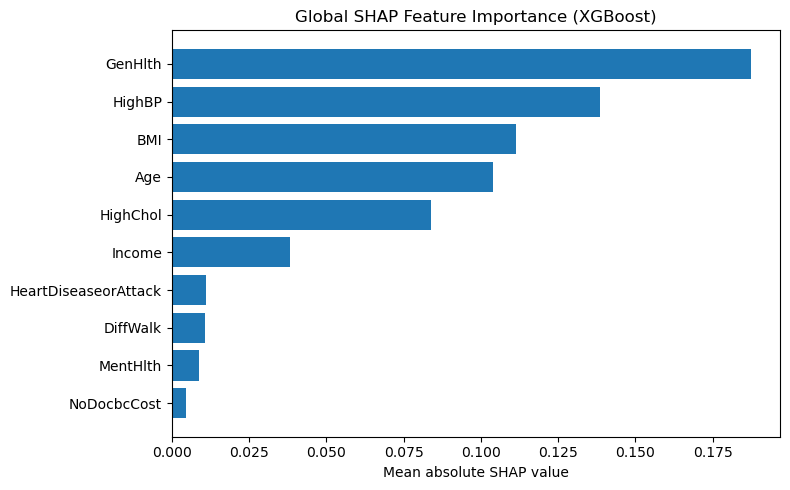

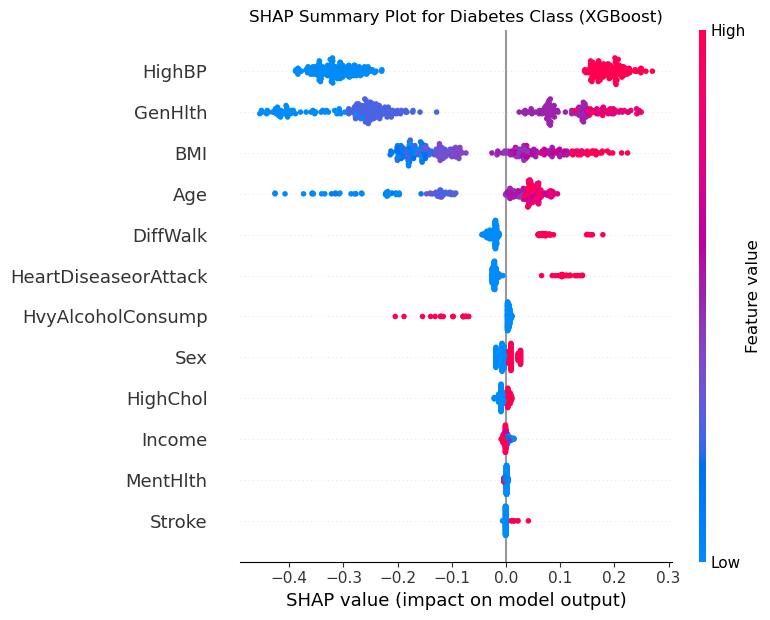


SHAP outputs saved to:
final_outputs/shap_feature_importance.csv
final_outputs/shap_global_bar.png
final_outputs/shap_summary_diabetes_class.png
final_outputs/shap_summary.json


In [13]:
# ============================================================
# 6. SHAP Explainability Output
# ============================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path("final_outputs")
OUT.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Choose tree-based model for SHAP
# Prefer XGBoost if available; otherwise fall back to Random Forest
# ------------------------------------------------------------

if "XGBoost" in models:
    shap_model_name = "XGBoost"
elif "Random Forest" in models:
    shap_model_name = "Random Forest"
else:
    raise ValueError("No tree-based model available for SHAP. Please train XGBoost or Random Forest first.")

kind, shap_model, decision_weights, model_setting = models[shap_model_name]

print("SHAP model used:", shap_model_name)
print("Model setting:", model_setting)

# ------------------------------------------------------------
# Use a sample of the test set to keep SHAP runtime manageable
# ------------------------------------------------------------

X_shap = X_test.sample(n=min(300, len(X_test)), random_state=RANDOM_STATE)

# ------------------------------------------------------------
# Compute SHAP values
# ------------------------------------------------------------

explainer = shap.TreeExplainer(shap_model)
shap_values_raw = explainer.shap_values(X_shap)

# ------------------------------------------------------------
# Convert SHAP output into a consistent format
# We focus on class 2 = Diabetes
# ------------------------------------------------------------

target_class = 2

if isinstance(shap_values_raw, list):
    # Common format for multiclass Random Forest:
    # list[class] -> array(n_samples, n_features)
    shap_values_class = shap_values_raw[target_class]
    mean_abs_shap = np.mean(
        np.abs(np.stack(shap_values_raw, axis=0)),
        axis=(0, 1)
    )

else:
    shap_array = np.asarray(shap_values_raw)

    if shap_array.ndim == 3:
        # Possible format 1: (n_samples, n_features, n_classes)
        if shap_array.shape[-1] == 3:
            shap_values_class = shap_array[:, :, target_class]
            mean_abs_shap = np.mean(np.abs(shap_array), axis=(0, 2))

        # Possible format 2: (n_classes, n_samples, n_features)
        elif shap_array.shape[0] == 3:
            shap_values_class = shap_array[target_class, :, :]
            mean_abs_shap = np.mean(np.abs(shap_array), axis=(0, 1))

        else:
            raise ValueError(f"Unexpected SHAP array shape: {shap_array.shape}")

    elif shap_array.ndim == 2:
        # Binary/single-output format
        shap_values_class = shap_array
        mean_abs_shap = np.mean(np.abs(shap_array), axis=0)

    else:
        raise ValueError(f"Unexpected SHAP output shape: {shap_array.shape}")

# ------------------------------------------------------------
# Save SHAP feature importance table
# ------------------------------------------------------------

shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values("MeanAbsSHAP", ascending=False)

shap_importance.to_csv(OUT / "shap_feature_importance.csv", index=False)

print("\nTop 10 SHAP features:")
print(shap_importance.head(10).round(4))

# ------------------------------------------------------------
# Plot 1: Global SHAP feature importance
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
top_features = shap_importance.head(10).iloc[::-1]

plt.barh(top_features["Feature"], top_features["MeanAbsSHAP"])
plt.xlabel("Mean absolute SHAP value")
plt.title(f"Global SHAP Feature Importance ({shap_model_name})")
plt.tight_layout()
plt.savefig(OUT / "shap_global_bar.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# Plot 2: SHAP summary plot for Diabetes class
# ------------------------------------------------------------

shap.summary_plot(
    shap_values_class,
    X_shap,
    max_display=12,
    show=False
)

plt.title(f"SHAP Summary Plot for Diabetes Class ({shap_model_name})")
plt.tight_layout()
plt.savefig(OUT / "shap_summary_diabetes_class.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# Save SHAP summary information
# ------------------------------------------------------------

shap_summary = {
    "shap_model_used": shap_model_name,
    "target_class_explained": "Diabetes class = 2",
    "sample_size": len(X_shap),
    "top_10_features": shap_importance.head(10)["Feature"].tolist()
}

pd.Series(shap_summary).to_json(OUT / "shap_summary.json", indent=2)

print("\nSHAP outputs saved to:")
print(OUT / "shap_feature_importance.csv")
print(OUT / "shap_global_bar.png")
print(OUT / "shap_summary_diabetes_class.png")
print(OUT / "shap_summary.json")

In [18]:
# ============================================================
# Create final metrics_df correctly before plotting
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score
)

OUT = Path("final_outputs")
OUT.mkdir(exist_ok=True)

def convert_decision_weights(decision_weights):
    """
    Convert decision weights into numpy array [w0, w1, w2].
    This fixes the error caused by multiplying probabilities by a dict.
    """
    if isinstance(decision_weights, dict):
        return np.array([
            decision_weights.get(0, 1.0),
            decision_weights.get(1, 1.0),
            decision_weights.get(2, 1.0)
        ], dtype=float)
    else:
        return np.asarray(decision_weights, dtype=float)


def get_model_prediction(model_name, model_info):
    """
    Get test-set prediction for one trained model.
    """
    kind, model, decision_weights, model_setting = model_info

    if kind == "scaled":
        proba = model.predict_proba(X_test_s)
    else:
        proba = model.predict_proba(X_test)

    weight_array = convert_decision_weights(decision_weights)
    pred = np.argmax(proba * weight_array, axis=1)

    return pred, proba, model_setting


rows = []
final_predictions = {}

for model_name, model_info in models.items():
    y_pred, y_proba, model_setting = get_model_prediction(model_name, model_info)

    final_predictions[model_name] = y_pred

    recalls = recall_score(
        y_test,
        y_pred,
        labels=[0, 1, 2],
        average=None,
        zero_division=0
    )

    rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Macro-F1": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "Healthy Recall": recalls[0],
        "Pre-diabetes Recall": recalls[1],
        "Diabetes Recall": recalls[2],
        "Setting": model_setting
    })

metrics_df = pd.DataFrame(rows).sort_values("Macro-F1", ascending=False)

metrics_df.to_csv(OUT / "model_metrics.csv", index=False)

print("metrics_df created successfully.")
display(metrics_df.round(4))
print("Saved to:", OUT / "model_metrics.csv")

metrics_df created successfully.


,Model,Accuracy,Balanced Accuracy,Macro-F1,Healthy Recall,Pre-diabetes Recall,Diabetes Recall,Setting
1,Random Forest,0.6916,0.5083,0.4312,0.6986,0.0994,0.7268,"80 trees, max_depth=12, class_weight=balanced_..."
0,Logistic Regression,0.6474,0.5279,0.4292,0.6627,0.3240,0.5971,"C=0.5, class_weight=balanced"
2,XGBoost,0.6356,0.5195,0.4208,0.6422,0.2732,0.6431,"30 trees, max_depth=3, lr=0.10, sample_weight=..."
3,Neural Network (MLP),0.8497,0.3777,0.3850,0.9839,0.0000,0.1492,"hidden=(32,), early stopping"


Saved to: final_outputs/model_metrics.csv


In [21]:
# ============================================================
# Create fairness_gaps_df before plotting fairness figure
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import f1_score

OUT = Path("final_outputs")
OUT.mkdir(exist_ok=True)

def convert_decision_weights(decision_weights):
    """
    Convert decision weights into array [w0, w1, w2].
    """
    if isinstance(decision_weights, dict):
        return np.array([
            decision_weights.get(0, 1.0),
            decision_weights.get(1, 1.0),
            decision_weights.get(2, 1.0)
        ], dtype=float)
    else:
        return np.asarray(decision_weights, dtype=float)


def predict_for_model(model_info, X_raw, X_scaled):
    """
    Generate predictions for one model using the saved decision weights.
    """
    kind, model, decision_weights, model_setting = model_info

    if kind == "scaled":
        proba = model.predict_proba(X_scaled)
    else:
        proba = model.predict_proba(X_raw)

    weight_array = convert_decision_weights(decision_weights)
    pred = np.argmax(proba * weight_array, axis=1)

    return pred


def subgroup_macro_f1_gap(y_true, y_pred, subgroup_values):
    """
    Calculate Macro-F1 for each subgroup and return the gap:
    max subgroup Macro-F1 - min subgroup Macro-F1.
    """
    temp = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "y_pred": np.asarray(y_pred),
        "group": np.asarray(subgroup_values)
    })

    subgroup_scores = []

    for group_value, group_df in temp.groupby("group"):
        if len(group_df) < 30:
            continue

        score = f1_score(
            group_df["y_true"],
            group_df["y_pred"],
            average="macro",
            zero_division=0
        )

        subgroup_scores.append({
            "Group": group_value,
            "Macro-F1": score,
            "N": len(group_df)
        })

    subgroup_scores = pd.DataFrame(subgroup_scores)

    if len(subgroup_scores) == 0:
        return np.nan, subgroup_scores

    gap = subgroup_scores["Macro-F1"].max() - subgroup_scores["Macro-F1"].min()

    return gap, subgroup_scores


# Sensitive / subgroup attributes used in the project
subgroup_attributes = ["Sex", "Age", "Income"]

fairness_gap_rows = []
fairness_detail_rows = []

for model_name, model_info in models.items():
    y_pred = predict_for_model(model_info, X_test, X_test_s)

    for attr in subgroup_attributes:
        gap, subgroup_scores = subgroup_macro_f1_gap(
            y_true=y_test,
            y_pred=y_pred,
            subgroup_values=X_test[attr]
        )

        fairness_gap_rows.append({
            "Model": model_name,
            "Attribute": attr,
            "Macro-F1 Gap": gap
        })

        if len(subgroup_scores) > 0:
            subgroup_scores["Model"] = model_name
            subgroup_scores["Attribute"] = attr
            fairness_detail_rows.append(subgroup_scores)

fairness_gaps_df = pd.DataFrame(fairness_gap_rows)
fairness_details_df = pd.concat(fairness_detail_rows, ignore_index=True)

fairness_gaps_df.to_csv(OUT / "fairness_gaps.csv", index=False)
fairness_details_df.to_csv(OUT / "fairness_details.csv", index=False)

print("fairness_gaps_df created successfully.")
display(fairness_gaps_df.round(4))

print("Saved to:")
print(OUT / "fairness_gaps.csv")
print(OUT / "fairness_details.csv")

fairness_gaps_df created successfully.


,Model,Attribute,Macro-F1 Gap
0,Logistic Regression,Sex,0.0019
1,Logistic Regression,Age,0.1770
2,Logistic Regression,Income,0.0796
3,Random Forest,Sex,0.0079
4,Random Forest,Age,0.1442
5,Random Forest,Income,0.0515
6,XGBoost,Sex,0.0007
7,XGBoost,Age,0.1350
8,XGBoost,Income,0.0494
9,Neural Network (MLP),Sex,0.0032


Saved to:
final_outputs/fairness_gaps.csv
final_outputs/fairness_details.csv


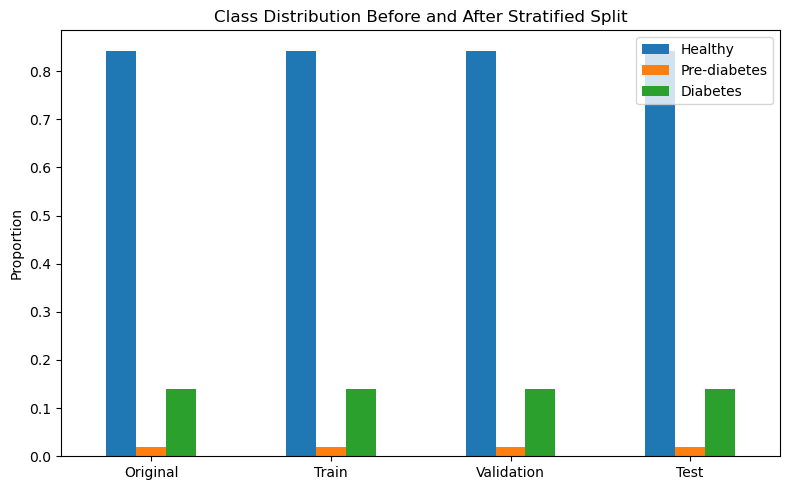

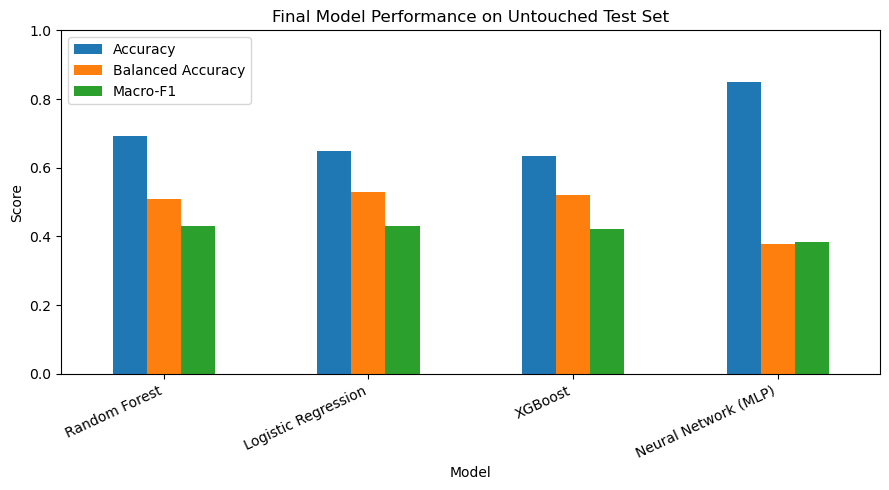

Best model for diagnostic plots: Random Forest
Decision weights used: [1. 1. 1.]


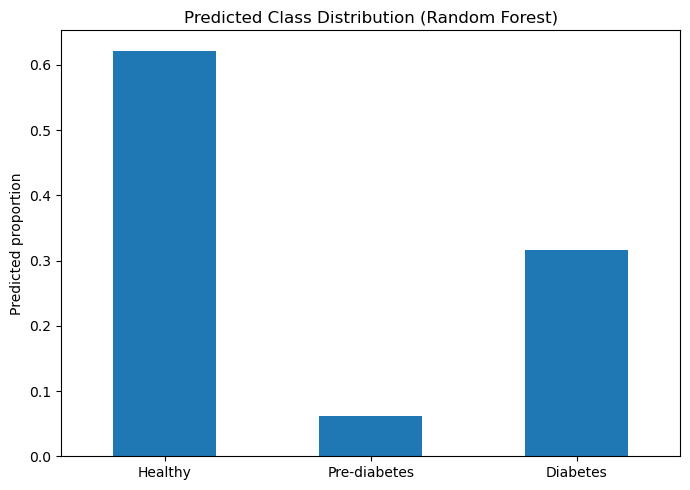

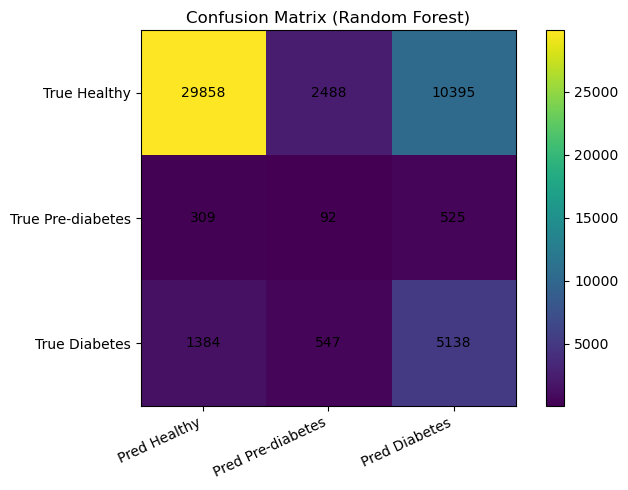

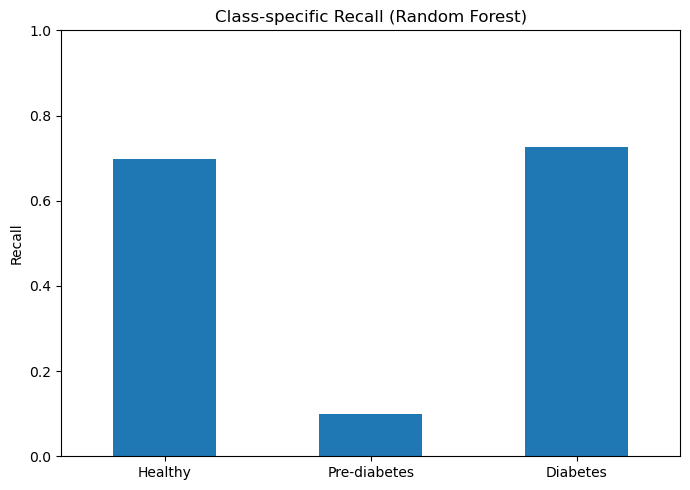

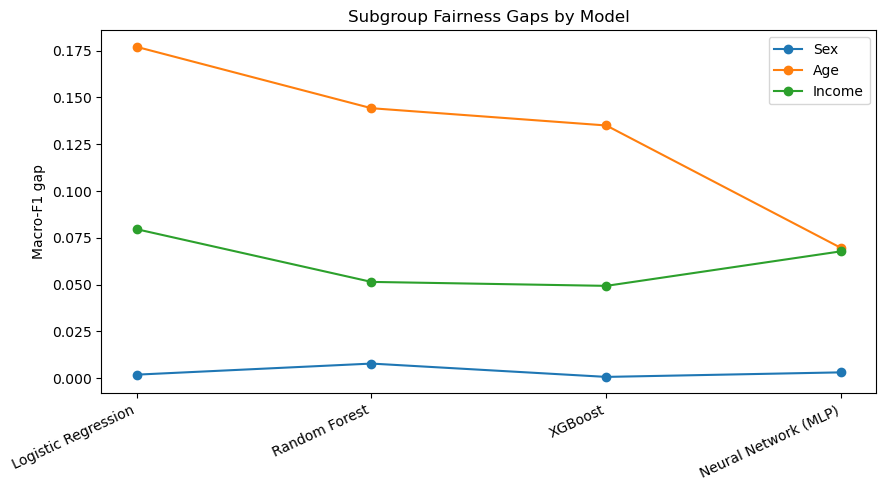

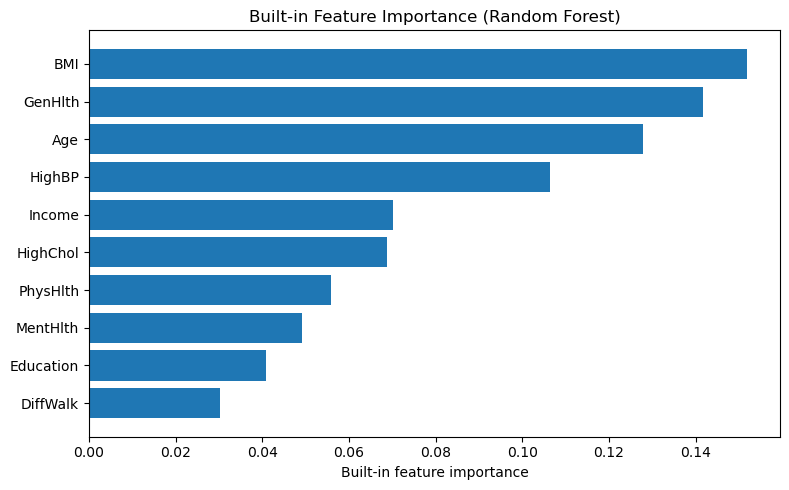

Final presentation figures saved to: final_charts


In [22]:
# ============================================================
# 7. Final Presentation Figures
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, recall_score

FIG = Path("final_charts")
FIG.mkdir(exist_ok=True)

# ------------------------------------------------------------
# 1. Class distribution plot
# ------------------------------------------------------------

dist_df = pd.DataFrame({
    "Original": y.value_counts(normalize=True).sort_index(),
    "Train": pd.Series(y_train).value_counts(normalize=True).sort_index(),
    "Validation": pd.Series(y_val).value_counts(normalize=True).sort_index(),
    "Test": pd.Series(y_test).value_counts(normalize=True).sort_index()
}).T

dist_df.columns = ["Healthy", "Pre-diabetes", "Diabetes"]

plt.figure(figsize=(8, 5))
dist_df.plot(kind="bar", ax=plt.gca())
plt.ylabel("Proportion")
plt.title("Class Distribution Before and After Stratified Split")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG / "class_distribution.png", dpi=300)
plt.show()


# ------------------------------------------------------------
# 2. Model performance plot
# Requires metrics_df from final evaluation
# ------------------------------------------------------------

metric_cols = ["Accuracy", "Balanced Accuracy", "Macro-F1"]

plt.figure(figsize=(9, 5))
metrics_df.set_index("Model")[metric_cols].plot(kind="bar", ax=plt.gca())
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Final Model Performance on Untouched Test Set")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIG / "model_performance.png", dpi=300)
plt.show()


# ------------------------------------------------------------
# 3. Select best model by Macro-F1 for diagnostic plots
# ------------------------------------------------------------

best_model_name = metrics_df.sort_values("Macro-F1", ascending=False).iloc[0]["Model"]
kind, best_model, best_tw, best_setting = models[best_model_name]

if kind == "scaled":
    proba_test = best_model.predict_proba(X_test_s)
else:
    proba_test = best_model.predict_proba(X_test)

# Convert decision weights into array format
# because tune_decision_weights() may return a dictionary like {0: 1.0, 1: 2.0, 2: 1.2}
if isinstance(best_tw, dict):
    best_tw_array = np.array([
        best_tw.get(0, 1.0),
        best_tw.get(1, 1.0),
        best_tw.get(2, 1.0)
    ], dtype=float)
else:
    best_tw_array = np.asarray(best_tw, dtype=float)

best_pred = np.argmax(proba_test * best_tw_array, axis=1)

print("Best model for diagnostic plots:", best_model_name)
print("Decision weights used:", best_tw_array)


# ------------------------------------------------------------
# 4. Best model prediction distribution
# ------------------------------------------------------------

pred_dist = pd.Series(best_pred).value_counts(normalize=True).sort_index()
pred_dist.index = ["Healthy", "Pre-diabetes", "Diabetes"]

plt.figure(figsize=(7, 5))
pred_dist.plot(kind="bar")
plt.ylabel("Predicted proportion")
plt.title(f"Predicted Class Distribution ({best_model_name})")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG / "best_model_pred_distribution.png", dpi=300)
plt.show()


# ------------------------------------------------------------
# 5. Best model confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test, best_pred, labels=[0, 1, 2])
cm_df = pd.DataFrame(
    cm,
    index=["True Healthy", "True Pre-diabetes", "True Diabetes"],
    columns=["Pred Healthy", "Pred Pre-diabetes", "Pred Diabetes"]
)

plt.figure(figsize=(7, 5))
plt.imshow(cm_df.values)
plt.colorbar()
plt.xticks(range(3), cm_df.columns, rotation=25, ha="right")
plt.yticks(range(3), cm_df.index)

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm_df.iloc[i, j], ha="center", va="center")

plt.title(f"Confusion Matrix ({best_model_name})")
plt.tight_layout()
plt.savefig(FIG / "best_model_confusion_matrix.png", dpi=300)
plt.show()


# ------------------------------------------------------------
# 6. Class-specific recall plot
# ------------------------------------------------------------

recalls = recall_score(y_test, best_pred, labels=[0, 1, 2], average=None, zero_division=0)
recall_df = pd.Series(
    recalls,
    index=["Healthy", "Pre-diabetes", "Diabetes"]
)

plt.figure(figsize=(7, 5))
recall_df.plot(kind="bar")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.title(f"Class-specific Recall ({best_model_name})")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG / "best_model_recall.png", dpi=300)
plt.show()


# ------------------------------------------------------------
# 7. Fairness gaps plot
# Requires fairness_gaps_df from fairness evaluation
# Expected columns: Model, Attribute, Macro-F1 Gap
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

for attr in fairness_gaps_df["Attribute"].unique():
    sub = fairness_gaps_df[fairness_gaps_df["Attribute"] == attr]
    plt.plot(sub["Model"], sub["Macro-F1 Gap"], marker="o", label=attr)

plt.ylabel("Macro-F1 gap")
plt.title("Subgroup Fairness Gaps by Model")
plt.xticks(rotation=25, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig(FIG / "fairness_gaps.png", dpi=300)
plt.show()


# ------------------------------------------------------------
# 8. Built-in tree feature importance
# This is NOT SHAP
# ------------------------------------------------------------

if "Random Forest" in models:
    tree_name = "Random Forest"
elif "XGBoost" in models:
    tree_name = "XGBoost"
else:
    tree_name = None

if tree_name is not None:
    _, tree_model, _, _ = models[tree_name]

    if hasattr(tree_model, "feature_importances_"):
        fi = pd.DataFrame({
            "Feature": X_train.columns,
            "Importance": tree_model.feature_importances_
        }).sort_values("Importance", ascending=False)

        fi.to_csv(FIG / "feature_importance.csv", index=False)

        top_fi = fi.head(10).iloc[::-1]

        plt.figure(figsize=(8, 5))
        plt.barh(top_fi["Feature"], top_fi["Importance"])
        plt.xlabel("Built-in feature importance")
        plt.title(f"Built-in Feature Importance ({tree_name})")
        plt.tight_layout()
        plt.savefig(FIG / "feature_importance.png", dpi=300)
        plt.show()


# ------------------------------------------------------------
# 9. Copy SHAP figures into final_charts if they exist
# ------------------------------------------------------------

for fname in ["shap_global_bar.png", "shap_summary_diabetes_class.png"]:
    src = OUT / fname
    dst = FIG / fname
    if src.exists():
        import shutil
        shutil.copy(src, dst)

print("Final presentation figures saved to:", FIG)